# くさび斜面上の符号付き合力 σ — まとめ

くさび形状の斜面上の計測点において，σ_tt（斜面接線方向の垂直応力）を求める手順をまとめる．

## 1. 座標系とくさびの形状

シミュレーションの座標系：
- **x 軸**：縦方向（下向きに増加，$x=0$ が上端，$x=n_x$ が底面）
- **z 軸**：横方向（右向きに増加）

1ピッチ分のくさびの形状（理想三角形）：

| 位置 | x 座標 | z 座標 |
|---|---|---|
| 深い端（溝の最深部） | $n_x - d_{\max}$ | $z_{\text{start}}$ |
| 浅い端（平坦面） | $n_x$ | $z_{\text{end}}$ |

斜面角度：
$$\theta = \arctan\!\left(\frac{\text{mn\_d}}{\text{mn\_p}}\right) = \arctan\!\left(\frac{d_{\max}}{p}\right)$$

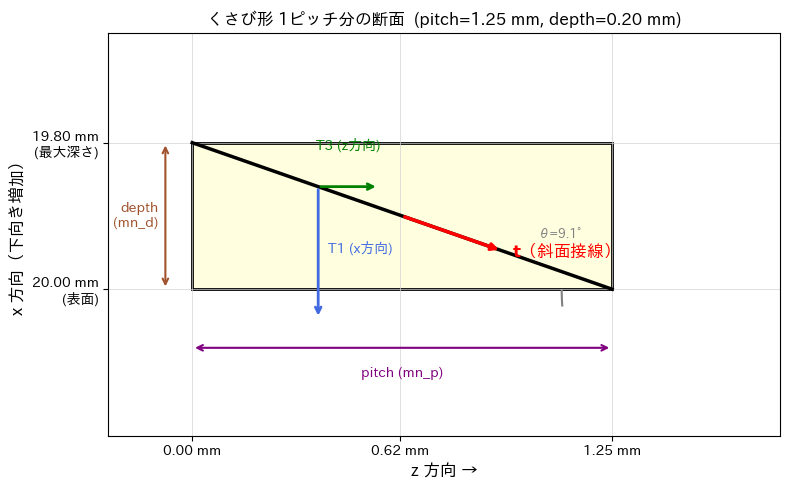

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import japanize_matplotlib

mn_p = 125   # pitch = 1.25 mm
mn_d = 20    # depth = 0.20 mm
nx   = 2000
z0   = 0
mesh = 1e-5

L     = np.sqrt(mn_d**2 + mn_p**2)
sin_t = mn_d / L
cos_t = mn_p / L
theta = np.degrees(np.arctan2(mn_d, mn_p))

fig, ax = plt.subplots(figsize=(8, 5))

solid_z = [z0, z0, z0+mn_p, z0+mn_p, z0]
solid_x = [nx-mn_d, nx, nx, nx-mn_d, nx-mn_d]
ax.fill(solid_z, solid_x, color='lightyellow', edgecolor='black', lw=2, zorder=1)
ax.plot([z0, z0+mn_p], [nx-mn_d, nx], 'k-', lw=2.5, zorder=3, label='斜面')

scale = 30
mid_z, mid_x = z0 + mn_p/2, nx - mn_d/2
ax.annotate('', xy=(mid_z + cos_t*scale, mid_x + sin_t*scale),
            xytext=(mid_z, mid_x),
            arrowprops=dict(arrowstyle='->', color='red', lw=2.5), zorder=5)
ax.text(mid_z + cos_t*scale + 3, mid_x + sin_t*scale,
        r'$\mathbf{t}$（斜面接線）', color='red', fontsize=12, va='center')

ex_z, ex_x, arr = z0 + mn_p*0.3, nx - mn_d*0.7, 18
ax.annotate('', xy=(ex_z, ex_x+arr), xytext=(ex_z, ex_x),
            arrowprops=dict(arrowstyle='->', color='royalblue', lw=2))
ax.text(ex_z+3, ex_x+arr*0.5, 'T1 (x方向)', color='royalblue', fontsize=10)
ax.annotate('', xy=(ex_z+arr, ex_x), xytext=(ex_z, ex_x),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.text(ex_z+arr*0.5, ex_x-5, 'T3 (z方向)', color='green', fontsize=10, ha='center')

ax.annotate('', xy=(z0, nx+8), xytext=(z0+mn_p, nx+8),
            arrowprops=dict(arrowstyle='<->', color='purple', lw=1.5))
ax.text(z0+mn_p/2, nx+12, 'pitch (mn_p)', ha='center', color='purple', fontsize=10)
ax.annotate('', xy=(z0-8, nx-mn_d), xytext=(z0-8, nx),
            arrowprops=dict(arrowstyle='<->', color='sienna', lw=1.5))
ax.text(z0-10, nx-mn_d/2, 'depth\n(mn_d)', ha='right', va='center', color='sienna', fontsize=10)

arc = mpatches.Arc((z0+mn_p, nx), 30, 30, angle=0,
                   theta1=180-theta, theta2=180, color='gray', lw=1.5)
ax.add_patch(arc)
ax.text(z0+mn_p-22, nx-7, f'θ={theta:.1f}°', fontsize=9, color='gray')

ax.set_xlim(z0-25, z0+mn_p+50)
ax.set_ylim(nx+20, nx-mn_d-15)
ax.set_xlabel('z 方向 →', fontsize=12)
ax.set_ylabel('x 方向（下向き増加）', fontsize=12)
ax.set_title(f'くさび形 1ピッチ分の断面  (pitch={mn_p*mesh*1e3:.2f} mm, depth={mn_d*mesh*1e3:.2f} mm)', fontsize=12)
ax.set_xticks([z0, z0+mn_p//2, z0+mn_p])
ax.set_xticklabels([f'{v*mesh*1e3:.2f} mm' for v in [z0, z0+mn_p//2, z0+mn_p]])
ax.set_yticks([nx-mn_d, nx])
ax.set_yticklabels([f'{(nx-mn_d)*mesh*1e3:.2f} mm\n(最大深さ)', f'{nx*mesh*1e3:.2f} mm\n(表面)'])
ax.grid(True, color='lightgray', lw=0.5)
plt.tight_layout()
plt.show()

## 2. 応力テンソルの定義

2次元の応力状態は以下の行列で表される：

$$\boldsymbol{\sigma} = \begin{pmatrix} T_1 & T_5 \\ T_5 & T_3 \end{pmatrix}$$

| 成分 | 意味 | 符号の意味 |
|---|---|---|
| $T_1 = \sigma_{xx}$ | x 方向垂直応力 | 正: 引張，負: 圧縮 |
| $T_3 = \sigma_{zz}$ | z 方向垂直応力 | 正: 引張，負: 圧縮 |
| $T_5 = \sigma_{xz}$ | せん断応力 | — |

## 3. 斜面接線方向の垂直応力 σ の導出

斜面を基準とした座標系（接線 $\mathbf{t}$，法線 $\mathbf{n}$）では，応力テンソルは以下の成分に分解される：

| 成分 | 名称 | 意味 |
|---|---|---|
| $\sigma_{tt} = \mathbf{t}^T \boldsymbol{\sigma}\, \mathbf{t}$ | **接線方向の垂直応力** | 斜面に沿って伸びる・縮む |
| $\sigma_{nn} = \mathbf{n}^T \boldsymbol{\sigma}\, \mathbf{n}$ | 法線方向の垂直応力 | 斜面を押す・引く |
| $\sigma_{tn}$ | せん断応力 | 斜面に沿って滑る |

今回求めるのは **$\sigma_{tt}$（斜面に沿った伸縮）** であり，斜面への垂直応力 $\sigma_{nn}$ とは別物である．

### 斜面接線ベクトル

$$\mathbf{t} = \begin{pmatrix} \sin\theta \\ \cos\theta \end{pmatrix}, \quad
\sin\theta = \frac{\text{mn\_d}}{L},\quad
\cos\theta = \frac{\text{mn\_p}}{L},\quad
L = \sqrt{\text{mn\_d}^2 + \text{mn\_p}^2}$$

### Cauchy の式による σ_tt の計算

$$\sigma_{tt} = \mathbf{t}^T \boldsymbol{\sigma} \, \mathbf{t}
= \begin{pmatrix} \sin\theta & \cos\theta \end{pmatrix}
\begin{pmatrix} T_1 & T_5 \\ T_5 & T_3 \end{pmatrix}
\begin{pmatrix} \sin\theta \\ \cos\theta \end{pmatrix}$$

$$\boxed{\sigma = \sigma_{tt} = T_1\sin^2\theta + 2T_5\sin\theta\cos\theta + T_3\cos^2\theta}$$

- $\sigma > 0$：斜面方向に**膨張**（引張）
- $\sigma < 0$：斜面方向に**縮小**（圧縮）

### T5 の計測点について

スタッガード格子上，$T_5$ ノードは物理位置 $x = (i+0.5)\,dx,\; z = j\,dz$ に配置される．
凸角（Uz ノード位置）から $x$ 方向に **0.5 メッシュ上の固体側ノード** $T_5[\mathtt{slope\_x}-1,\; \mathtt{slope\_z}]$ を計測点として使用する．

## 4. 各パラメータにおける θ と sin²θ, cos²θ の値

θ が小さいほど斜面は緩やかで，$\cos^2\theta \approx 1$，$\sin^2\theta \approx 0$ となる．

In [2]:
import numpy as np

params = [
    (1.25e-3, 0.10e-3),
    (1.25e-3, 0.20e-3),
    (2.00e-3, 0.10e-3),
    (2.00e-3, 0.20e-3),
]
mesh = 1e-5

print(f"{'pitch':>8} {'depth':>8} {'θ [°]':>8} {'sin²θ':>8} {'cos²θ':>8} {'2sinθcosθ':>12}")
print('-' * 60)
for p, d in params:
    mn_p = int(round(p / mesh))
    mn_d = int(round(d / mesh))
    L    = np.sqrt(mn_p**2 + mn_d**2)
    theta = np.degrees(np.arctan2(mn_d, mn_p))
    sin_t = mn_d / L
    cos_t = mn_p / L
    print(f"{p*1e3:>7.2f}mm {d*1e3:>7.2f}mm {theta:>8.2f} {sin_t**2:>8.4f} {cos_t**2:>8.4f} {2*sin_t*cos_t:>12.4f}")

   pitch    depth    θ [°]    sin²θ    cos²θ    2sinθcosθ
------------------------------------------------------------
   1.25mm    0.10mm     4.57   0.0064   0.9936       0.1590
   1.25mm    0.20mm     9.09   0.0250   0.9750       0.3120
   2.00mm    0.10mm     2.86   0.0025   0.9975       0.0998
   2.00mm    0.20mm     5.71   0.0099   0.9901       0.1980


## 5. θ が小さい場合の近似（重要な注意点）

くさびの斜面角度は $\theta \approx 3^\circ \sim 9^\circ$ と非常に小さいため：

$$\sin^2\theta \approx 0, \quad \cos^2\theta \approx 1, \quad \sin\theta\cos\theta \approx 0$$

したがって：

$$\sigma = \sigma_{tt} \approx T_3$$

**→ σ グラフが T3 グラフとほぼ同一になるのは数学的に必然であり，正常な結果である．**

## 6. σ_tt ≈ T3 の近似が成り立つ理由の詳細検証

セクション5では「θ が小さいので σ_tt ≈ T3」と結論したが，これは **T5 の大きさを無視した場合** の近似である．  
実際のシミュレーション結果（`plot_kusabi_T135_slope_check.py` による確認，pitch=2.00mm, depth=0.20mm, edge）では，以下の値が得られた．

| 成分 | 最大値 | σ_tt への寄与 | 全体に占める割合 |
|------|--------|--------------|----------------|
| T1   | 0.0836 Pa | 0.0008 Pa | ~0% |
| T3   | 0.4616 Pa | 0.4571 Pa | ~83% |
| T5   | 0.4764 Pa | 0.0943 Pa | ~17% |
| **σ_tt 合計** | | **~0.552 Pa** | |

### 注目点：T5 ≈ T3 の大きさ

θ ≈ 5.7° の滑らかな傾斜面であれば，変換式から：

$$\frac{T_5}{T_3} = \tan\theta \approx 0.1$$

が期待されるが，実測では **T5 ≈ T3**（0.476 ≈ 0.462）となっている．

**理由：計測点が滑らかな斜面上にない**  
計測点は階段近似の **凸角（staircase corner）** であり，水平面と垂直面が交わる特異点である．  
この点では滑らかな自由表面の仮定が成り立たず，T5 が T3 と同程度の大きさを持ちうる．  
また T5 は凸角から x 方向に 0.5 メッシュ上の固体内部ノードで計測しており，厳密な自由表面上ではない．

### T3 と T5 の波形が同じ形をしている理由

シミュレーション結果では **T3 と T5 の時空間マップが同じ形** を示す．  
これは，凸角を通過する波動が T3 と T5 の両方を同じ時間変化で励起するためである．  
比例関係 $T_5 \approx \alpha T_3$（α ≈ 1）が成り立つとみなせる．

### σ_tt の実際の近似

$T_5 \approx T_3$（α ≈ 1）とすると：

$$\sigma_{tt} = T_1\sin^2\theta + 2T_5\sin\theta\cos\theta + T_3\cos^2\theta
\approx T_3(\cos^2\theta + 2\sin\theta\cos\theta)$$

pitch=2.00mm, depth=0.20mm の場合：

$$\sigma_{tt} \approx T_3 \times (0.9901 + 0.1980) \approx 1.19 \cdot T_3$$

実測の寄与の合計からは $0.552 / 0.4571 \approx 1.21$ となり，ほぼ一致する．

**→ σ_tt は T3 と同じ形をもち，振幅が約 1.2 倍になる**  
これが σ_tt のカラーバーが T3 より「少し広い」ことの説明である．

なお **T1 の寄与（0.0008 Pa）は完全に無視できる**レベルであり，σ_tt ≈ T3 の近似が崩れる主因は T5 項（17%）である．

In [3]:
import numpy as np

mesh = 1e-5
params = [
    (1.25e-3, 0.10e-3),
    (1.25e-3, 0.20e-3),
    (2.00e-3, 0.10e-3),
    (2.00e-3, 0.20e-3),
]

print("T5 ≈ T3 と仮定した場合の σ_tt / T3 の比")
print(f"{'pitch':>8} {'depth':>8} {'θ [°]':>8} {'cos²θ':>8} {'2sinθcosθ':>12} {'σ_tt/T3':>10}")
print('-' * 62)
for p, d in params:
    mn_p = int(round(p / mesh))
    mn_d = int(round(d / mesh))
    L     = np.sqrt(mn_p**2 + mn_d**2)
    sin_t = mn_d / L
    cos_t = mn_p / L
    theta = np.degrees(np.arctan2(mn_d, mn_p))
    ratio = cos_t**2 + 2 * sin_t * cos_t   # T5 ≈ T3 と仮定
    print(f"{p*1e3:>7.2f}mm {d*1e3:>7.2f}mm {theta:>8.2f} {cos_t**2:>8.4f} {2*sin_t*cos_t:>12.4f} {ratio:>10.4f}")

T5 ≈ T3 と仮定した場合の σ_tt / T3 の比
   pitch    depth    θ [°]    cos²θ    2sinθcosθ    σ_tt/T3
--------------------------------------------------------------
   1.25mm    0.10mm     4.57   0.9936       0.1590     1.1526
   1.25mm    0.20mm     9.09   0.9750       0.3120     1.2871
   2.00mm    0.10mm     2.86   0.9975       0.0998     1.0973
   2.00mm    0.20mm     5.71   0.9901       0.1980     1.1881
